# Spatial Polygon Merging (SPM) Benchmarking

This notebook is used to benchmark the merging performance of the SPM algorithm against other merging methods on images of various sizes. The test dataset is generated by cropping a large image into smaller tiles of different sizes. A fine-tuned model is then used to predict the segmentations in each tile, and fragmented predictions are merged using the SPM algorithm and other methods. The merging performance for each method is then evaluated based on the mAP, precision, recall, and F1-score of the merged polygons compared to the ground truth polygons.

### Benchmark Test Dataset Generation

The WHU Building Dataset provides an uncropped version of the dataset, which contains a large aerial image and its corresponding shapefile of building polygons. The image and shapefile is downloaded and stored in the `test_images` folder. The image and shapefile are then passed to the `generate` command of the benchmark module, which crops the image into smaller tiles of different sizes and saves them in the `benchmark_test_set` folder.

In [14]:
!cd ../ && \
uv run python -m benchmark generate \
"test_images/1.the whole aerial image.tif" \
"test_images/2. The shape file of the whole area/allbuilding.shp" \
benchmark_test_set \
--crop-sizes 5000 10000 20000 50000 100000 \
--stride-ratio 1.0 \
--max-crops 1

[2026-07-13 09:55:48.922470] WARNING - Repairing 4 invalid label geometries (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:65:generate_test_set())
[2026-07-13 09:56:00.102950] INFO - Created 412 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:00.105718] INFO - Wrote crop benchmark_test_set/crop_5000_0/image.tif with 412 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:08.371832] INFO - Created 1,505 records (/media/vince/Backup/Projects/spatial_polygon_merging/.venv/lib/python3.11/site-packages/pyogrio/raw.py:733:write())
[2026-07-13 09:56:08.375627] INFO - Wrote crop benchmark_test_set/crop_10000_0/image.tif with 1505 labels (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/crops.py:100:generate_test_set())
[2026-07-13 09:56:26.490117] INFO - Created 5,250 records (/media/vince/B

### Benchmark Report Generation (CLI)

In [ ]:
!cd ../ && \
uv run python -m benchmark evaluate \
benchmark_test_set \
"runs/segment/yolo-seg-whu/weights/best.pt" \
--device cuda \
--batch-size 4 \
--conf 0.3 \
--tile-size 1500 \
--overlap 0.1 \
--iou 0.5 \
--output notebooks/results/benchmark_results.csv

[2026-07-13 10:35:26.314899] INFO - Benchmarking 5 crops with 7 methods (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/runner.py:45:benchmark_test_set())
[2026-07-13 10:35:26.330869] INFO - Performing prediction on image: benchmark_test_set/crop_100000_0/image.tif (width: 100000, height: 100000) (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:79:predict())
[2026-07-13 10:41:08.597180] INFO - Total tiles processed: 5476 (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/models/yolo.py:169:predict())
[2026-07-13 10:41:13.918340] INFO - Running SPM with config: SPMConfig(tau_dist=1.0, tau_chain=5), merge_only_seam=True (/media/vince/Backup/Projects/spatial_polygon_merging/benchmark/methods.py:167:merge_spm())
[2026-07-13 10:41:13.920157] INFO - Indexing polygons for merging (/media/vince/Backup/Projects/spatial_polygon_merging/src/spm/merging/spm.py:20:index())
[2026-07-13 10:41:45.646054] INFO - Created 61,470 records (/media/vince

In [33]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [34]:
# Load benchmark results
df = pd.read_csv("results/benchmark_results.csv")
df.sort_values(by=["crop_size", "method"], inplace=True, ignore_index=True)
df

,crop,crop_size,method,merge_time,peak_memory_usage,num_gt,num_pred,mAP,mAP50,mAP75,precision,recall,f1
0,crop_5000_0,5000,sahi_greedy_nmm,0.175874,54.433594,416,470,0.551469,0.865222,0.640874,0.806383,0.911058,0.855530
1,crop_5000_0,5000,sahi_lsnms,6.122693,225.742188,416,470,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
2,crop_5000_0,5000,sahi_nmm,0.184751,54.597656,416,465,0.552109,0.859982,0.642642,0.812903,0.908654,0.858116
3,crop_5000_0,5000,sahi_nms,0.014517,54.414062,416,470,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
4,crop_5000_0,5000,smm,183.540619,26944.042969,416,438,0.555125,0.887858,0.628061,0.863014,0.908654,0.885246
5,crop_5000_0,5000,spm_global,0.118006,5.550781,416,406,0.562491,0.874279,0.649131,0.911330,0.889423,0.900243
6,crop_5000_0,5000,spm_seam_only,0.114826,5.515625,416,409,0.564361,0.883518,0.656336,0.907090,0.891827,0.899394
7,crop_10000_0,10000,sahi_greedy_nmm,0.756204,252.871094,1515,1763,0.558868,0.864475,0.656341,0.783891,0.912211,0.843197
8,crop_10000_0,10000,sahi_lsnms,6.241711,227.542969,1515,1763,0.536583,0.847848,0.610847,0.780488,0.908251,0.839536
9,crop_10000_0,10000,sahi_nmm,0.826789,252.910156,1515,1752,0.558416,0.865123,0.656248,0.787671,0.910891,0.844812


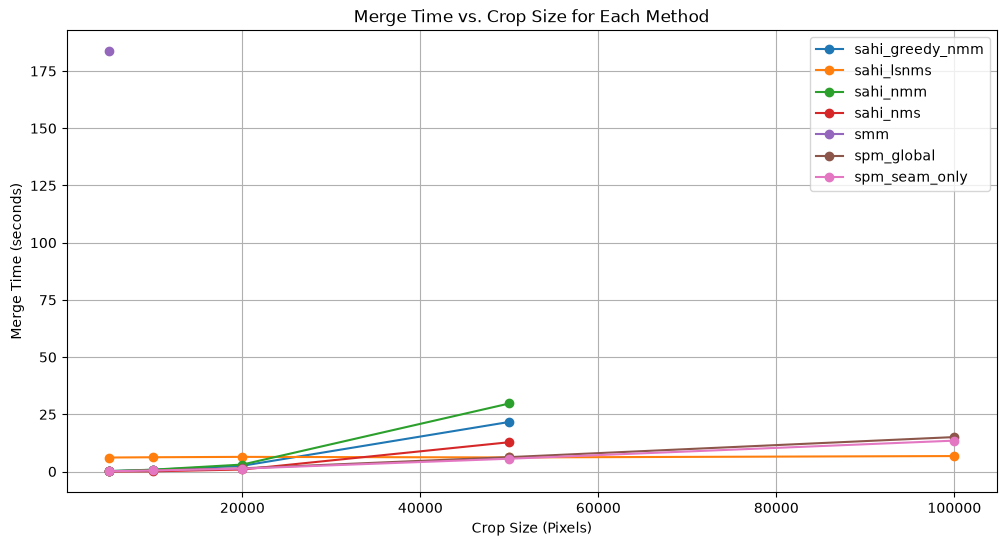

In [35]:
# Visualize merge_time vs. crop_size for each method
plt.figure(figsize=(12, 6))
for method in df["method"].unique():
    method_data = df[df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["merge_time"], marker='o', label=method)
plt.title("Merge Time vs. Crop Size for Each Method")
plt.xlabel("Crop Size (Pixels)")
plt.ylabel("Merge Time (seconds)")
plt.legend()
plt.grid()
plt.savefig("results/merge_time_vs_crop_size.png")
plt.show()

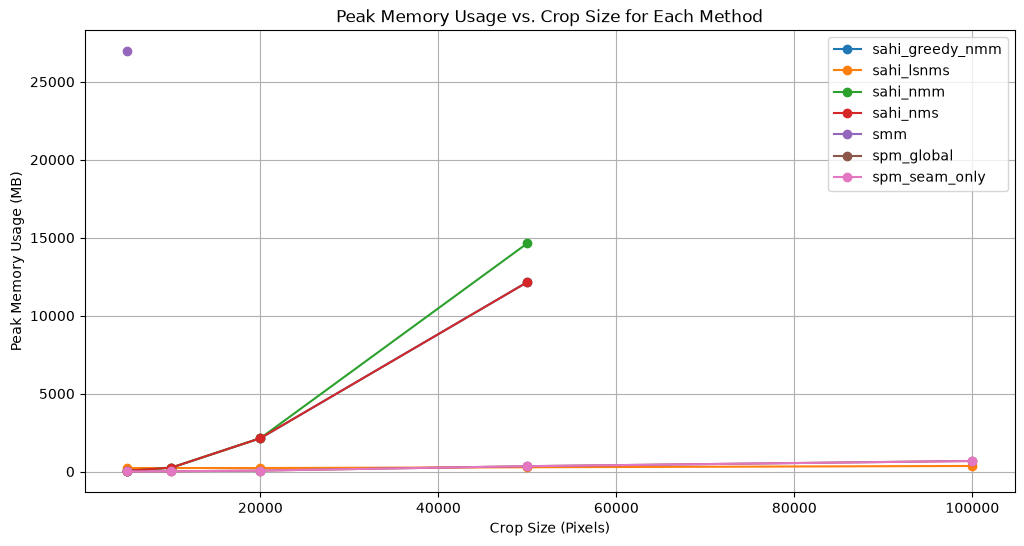

In [36]:
# Visualize peak_memory_usage vs. number of polygons for each method
plt.figure(figsize=(12, 6))
for method in df["method"].unique():
    method_data = df[df["method"] == method]
    plt.plot(method_data["crop_size"], method_data["peak_memory_usage"], marker='o', label=method)
plt.title("Peak Memory Usage vs. Crop Size for Each Method")
plt.xlabel("Crop Size (Pixels)")
plt.ylabel("Peak Memory Usage (MB)")
plt.legend()
plt.grid()
plt.savefig("results/peak_memory_usage_vs_crop_size.png")
plt.show()

In [ ]:
# Get the metrics for each method at the 5000 crop size (where all methods have results)
df_metrics_5000 = df[df["crop_size"] == 5000][["method","mAP", "mAP50", "mAP75", "precision", "recall", "f1"]]
df_metrics_5000

,method,mAP,mAP50,mAP75,precision,recall,f1
0,sahi_greedy_nmm,0.551469,0.865222,0.640874,0.806383,0.911058,0.855530
1,sahi_lsnms,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
2,sahi_nmm,0.552109,0.859982,0.642642,0.812903,0.908654,0.858116
3,sahi_nms,0.507563,0.831419,0.572477,0.795745,0.899038,0.844244
4,smm,0.555125,0.887858,0.628061,0.863014,0.908654,0.885246
5,spm_global,0.562491,0.874279,0.649131,0.911330,0.889423,0.900243
6,spm_seam_only,0.564361,0.883518,0.656336,0.907090,0.891827,0.899394


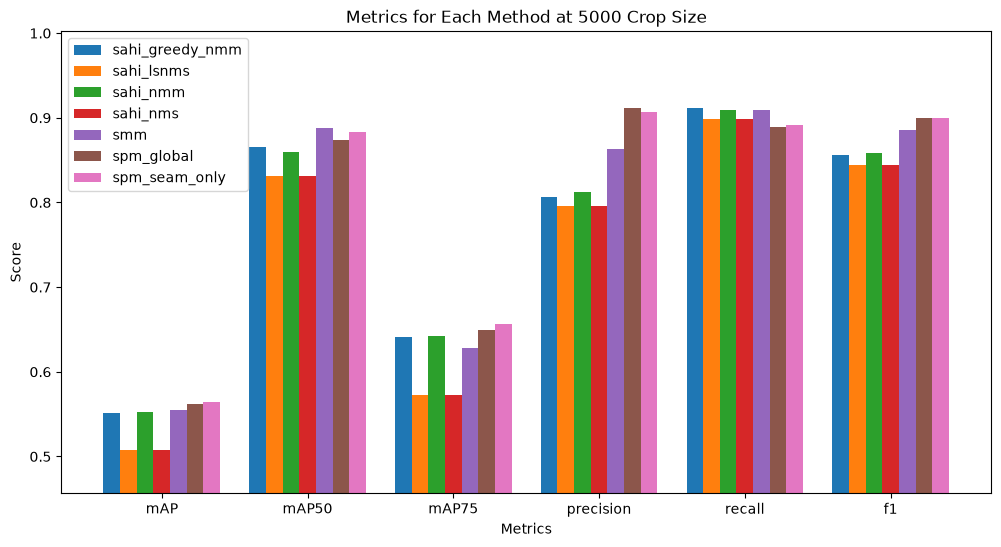

In [37]:
categories = df_metrics_5000.columns[1:] # exclude "method", "merge_time", and "peak_memory_usage"
n = len(df_metrics_5000)
x = np.arange(len(categories))
# print(f"Categories: {categories}, Number of methods: {n}, X positions: {x}")
width = 0.8 / n

fig, ax = plt.subplots(figsize=(12, 6))

for i, row in df_metrics_5000.iterrows():
    offset = (i - (n - 1) / 2 ) * width
    # print(f"Row: {row['method']}, Offset: {offset}, Width: {width}, X positions: {x + offset}")
    ax.bar(x+offset, row[categories], width=width, label=row["method"], align='center', bottom=None)

ax.set_xticks(x)
ax.set_ylim(df_metrics_5000[categories].min().values.min() * 0.9, df_metrics_5000[categories].max().values.max() * 1.1)
ax.set_xticklabels(categories)
ax.legend()
ax.set_title("Metrics for Each Method at 5000 Crop Size")
ax.set_xlabel("Metrics")
ax.set_ylabel("Score")
plt.savefig("results/metrics_for_each_method_at_5000_crop_size.png")